# FinBERT Example Notebook

This notebooks shows how to train and use the FinBERT pre-trained language model for financial sentiment analysis.

## Modules 

In [1]:
from pathlib import Path
import shutil
import os
import logging
import sys
sys.path.append('..')

from textblob import TextBlob
from pprint import pprint
from sklearn.metrics import classification_report, balanced_accuracy_score

from transformers import AutoModelForSequenceClassification

from finbert.finbert import *
import finbert.utils as tools

%load_ext autoreload
%autoreload 2

project_dir = Path.cwd().parent
pd.set_option('max_colwidth', None)

In [2]:
logging.basicConfig(format = '%(asctime)s - %(levelname)s - %(name)s -   %(message)s',
                    datefmt = '%m/%d/%Y %H:%M:%S',
                    level = logging.ERROR)

## Prepare the model

### Setting path variables:
1. `lm_path`: the path for the pre-trained language model (If vanilla Bert is used then no need to set this one).
2. `cl_path`: the path where the classification model is saved.
3. `cl_data_path`: the path of the directory that contains the data files of `train.csv`, `validation.csv`, `test.csv`.
---

In the initialization of `bertmodel`, we can either use the original pre-trained weights from Google by giving `bm = 'bert-base-uncased`, or our further pre-trained language model by `bm = lm_path`


---
All of the configurations with the model is controlled with the `config` variable. 

In [3]:
import requests
import os
import shutil
from pathlib import Path
from tqdm import tqdm

# Directory to store the downloaded model
MODEL_DIR = './models/language_model'
os.makedirs(MODEL_DIR, exist_ok=True)

# Model file URLs
BASE_URL = 'https://prosus-public.s3-eu-west-1.amazonaws.com/finbert/language-model'
FILE_TO_DOWNLOAD = 'pytorch_model.bin'
MODEL_NAME = 'finbertTRC2'


def download_file(url, dest_path):
    """Download a file from a URL to the destination path with progress indicator."""
    print(f'Downloading {url} to {dest_path}...')

    if os.path.exists(dest_path):
        print(f'File already exists: {dest_path}')
        return True

    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()
        
        # Get the total file size from headers
        total_size = int(response.headers.get('content-length', 0))
        
        with open(dest_path, 'wb') as f:
            with tqdm(total=total_size, unit='B', unit_scale=True, unit_divisor=1024, desc=os.path.basename(dest_path)) as pbar:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))

        print(f'✓ Successfully downloaded: {dest_path}')
        return True
    except Exception as e:
        print(f'✗ Error downloading {url}: {e}')
        return False


# Download model files
print('='*100)
print('Downloading FinBERT Language Model from S3...')
print('='*100)

all_downloaded = True

# Create model directory
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
model_dir = os.path.join(project_root, MODEL_DIR, MODEL_NAME)
# Check if path exists and is a file (not a directory)
if os.path.exists(model_dir) and os.path.isfile(model_dir):
    print(f'Warning: {model_dir} exists as a file. Removing it to create directory...')
    os.remove(model_dir)
os.makedirs(model_dir, exist_ok=True)


# Download pytorch_model.bin
url = f'{BASE_URL}/{FILE_TO_DOWNLOAD}'
dest_path = os.path.join(model_dir, FILE_TO_DOWNLOAD)
if not download_file(url, dest_path):
    all_downloaded = False

# Copy config.json to the same destination
# config.json is in the project root, notebooks are in notebooks/ subdirectory
config_source = project_root / 'config.json'

if config_source.exists():
    config_dest = os.path.join(model_dir, 'config.json')
    if not os.path.exists(config_dest):
        print(f'Copying config.json to {config_dest}...')
        shutil.copy2(str(config_source), config_dest)
        print(f'✓ Successfully copied config.json')
    else:
        print(f'config.json already exists: {config_dest}')
else:
    print(f'✗ Warning: config.json not found at {config_source}')
    all_downloaded = False

if all_downloaded:
    print('\n' + '='*100)
    print('All files were downloaded successfully!')
    print('='*100)
else:
    print('\n' + '='*100)
    print('Some files could not be downloaded. Check the errors above.')
    print('='*100)

File already exists: /Users/bruno/ws/finBERT/./models/language_model/finbertTRC2/pytorch_model.bin
config.json already exists: /Users/bruno/ws/finBERT/./models/language_model/finbertTRC2/config.json

All files were downloaded successfully!


In [4]:
lm_path = project_dir/'models'/'language_model'/'finbertTRC2'
cl_path = project_dir/'models'/'classifier_model'/'finbert-sentiment'
cl_data_path = project_dir/'data'/'sentiment_data'

###  Configuring training parameters

You can find the explanations of the training parameters in the class docsctrings. 

In [5]:
# Clean the cl_path
try:
    shutil.rmtree(cl_path)
except:
    pass

# Convert to absolute path string
import os
import json
from transformers import BertConfig
lm_path_str = os.path.abspath(str(lm_path))

# Check if the model path exists
if not os.path.exists(lm_path_str):
    print(f"Warning: Model path does not exist: {lm_path_str}")
    print("You can either:")
    print("1. Download the model and place it in the above path")
    print("2. Use 'bert-base-uncased' instead by setting: bertmodel = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)")
    print("\nTrying to use 'bert-base-uncased' as fallback...")
    bertmodel = AutoModelForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=3)
else:
    # Check if the path is a file or directory
    if os.path.isfile(lm_path_str):
        # If it's a file, we need to create a proper directory structure
        # Create a directory with the same name (without extension)
        model_dir = lm_path_str + "_dir"
        os.makedirs(model_dir, exist_ok=True)

        # Move/copy the model file to pytorch_model.bin in the directory
        model_file_path = os.path.join(model_dir, "pytorch_model.bin")
        if not os.path.exists(model_file_path):
            import shutil
            shutil.copy2(lm_path_str, model_file_path)

        # Create config.json from bert-base-uncased config
        config_path = os.path.join(model_dir, "config.json")
        if not os.path.exists(config_path):
            bert_config = BertConfig.from_pretrained('bert-base-uncased')
            bert_config.save_pretrained(model_dir)

        # Use the directory path instead
        lm_path_str = model_dir

    # Path exists and is a directory, load from local directory
    # Note: For newer transformers versions, we need to ensure the path is recognized as local
    # Use Path object or ensure it's a string that transformers can handle
    bertmodel = AutoModelForSequenceClassification.from_pretrained(
        str(lm_path_str),
        cache_dir=None,
        num_labels=3,
        local_files_only=True
    )


config = Config(data_dir=cl_data_path,
                bert_model=bertmodel,
                num_train_epochs=10,
                model_dir=cl_path,
                max_seq_length=48,
                train_batch_size=32,
                learning_rate=2e-5,
                output_mode='classification',
                warm_up_proportion=0.2,
                local_rank=-1,
                discriminate=True,
                gradual_unfreeze=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /Users/bruno/ws/finBERT/models/language_model/finbertTRC2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


`finbert` is our main class that encapsulates all the functionality. The list of class labels should be given in the prepare_model method call with label_list parameter.

In [6]:
finbert = FinBert(config)
finbert.base_model = 'bert-base-uncased'
finbert.config.discriminate=True
finbert.config.gradual_unfreeze=True

In [7]:
finbert.prepare_model(label_list=['positive','negative','neutral'])

12/08/2025 02:22:26 - INFO - finbert.finbert -   device: mps n_gpu: 1, distributed training: False, 16-bits training: False


## Fine-tune the model

In [8]:
# Get the training examples
train_data = finbert.get_data('train')

12/08/2025 02:22:26 - INFO - finbert.finbert -   Class weights: tensor([3.5856, 7.7988, 1.6867])


In [9]:
model = finbert.create_the_model()

### [Optional] Fine-tune only a subset of the model
The variable `freeze` determines the last layer (out of 12) to be freezed. You can skip this part if you want to fine-tune the whole model.

<span style="color:red">Important: </span>
Execute this step if you want a shorter training time in the expense of accuracy.

In [10]:
# This is for fine-tuning a subset of the model.

# freeze = 6

# for param in model.bert.embeddings.parameters():
#     param.requires_grad = False
    
# for i in range(freeze):
#     for param in model.bert.encoder.layer[i].parameters():
#         param.requires_grad = False

### Training

In [11]:
trained_model = finbert.train(train_examples = train_data, model = model)

12/08/2025 02:22:26 - INFO - finbert.utils -   Label map: {'positive': 0, 'negative': 1, 'neutral': 2, None: 9090}
12/08/2025 02:22:26 - INFO - finbert.utils -   Label list: ['positive', 'negative', 'neutral']
12/08/2025 02:22:26 - INFO - finbert.utils -   *** Example ***
12/08/2025 02:22:26 - INFO - finbert.utils -   guid: train-1
12/08/2025 02:22:26 - INFO - finbert.utils -   tokens: [CLS] tel ##ias ##one ##ra s subsidiary , the mobile operator em ##t in estonia , has created a world s first mobile identification service which makes it possible to vote via a mobile phone . [SEP]
12/08/2025 02:22:26 - INFO - finbert.utils -   input_ids: 101 10093 7951 5643 2527 1055 7506 1010 1996 4684 6872 7861 2102 1999 10692 1010 2038 2580 1037 2088 1055 2034 4684 8720 2326 2029 3084 2009 2825 2000 3789 3081 1037 4684 3042 1012 102 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:22:26 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 

Iteration:   0%|          | 0/122 [00:00<?, ?it/s]

12/08/2025 02:22:32 - INFO - finbert.utils -   *** Example ***
12/08/2025 02:22:32 - INFO - finbert.utils -   guid: validation-1
12/08/2025 02:22:32 - INFO - finbert.utils -   tokens: [CLS] ` ` my wife is looking forward to getting a pay ##che ##ck again , ' ' he qui ##pped recently as a six - knot current swirled around his anchored and heavily sponsored jet sl ##ed . [SEP]
12/08/2025 02:22:32 - INFO - finbert.utils -   input_ids: 101 1036 1036 2026 2564 2003 2559 2830 2000 2893 1037 3477 5403 3600 2153 1010 1005 1005 2002 21864 11469 3728 2004 1037 2416 1011 12226 2783 19171 2105 2010 14453 1998 4600 6485 6892 22889 2098 1012 102 0 0 0 0 0 0 0 0
12/08/2025 02:22:32 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
12/08/2025 02:22:32 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:22:32 - INFO

Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Validation losses: [1.0861921235918999]
No best model found


...

Iteration:   0%|          | 0/122 [00:00<?, ?it/s]

12/08/2025 02:24:38 - INFO - finbert.utils -   *** Example ***
12/08/2025 02:24:38 - INFO - finbert.utils -   guid: validation-1
12/08/2025 02:24:38 - INFO - finbert.utils -   tokens: [CLS] ` ` my wife is looking forward to getting a pay ##che ##ck again , ' ' he qui ##pped recently as a six - knot current swirled around his anchored and heavily sponsored jet sl ##ed . [SEP]
12/08/2025 02:24:38 - INFO - finbert.utils -   input_ids: 101 1036 1036 2026 2564 2003 2559 2830 2000 2893 1037 3477 5403 3600 2153 1010 1005 1005 2002 21864 11469 3728 2004 1037 2416 1011 12226 2783 19171 2105 2010 14453 1998 4600 6485 6892 22889 2098 1012 102 0 0 0 0 0 0 0 0
12/08/2025 02:24:38 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
12/08/2025 02:24:38 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:24:38 - INFO

Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch: 100%|██████████| 10/10 [02:12<00:00, 13.22s/it]

Validation losses: [1.0861921235918999, 0.5527442414313555, 0.36417553201317787, 0.345830918289721, 0.3286827811971307, 0.3536638580262661, 0.3501699222251773, 0.3553966796025634, 0.36424442287534475, 0.3634545346722007]


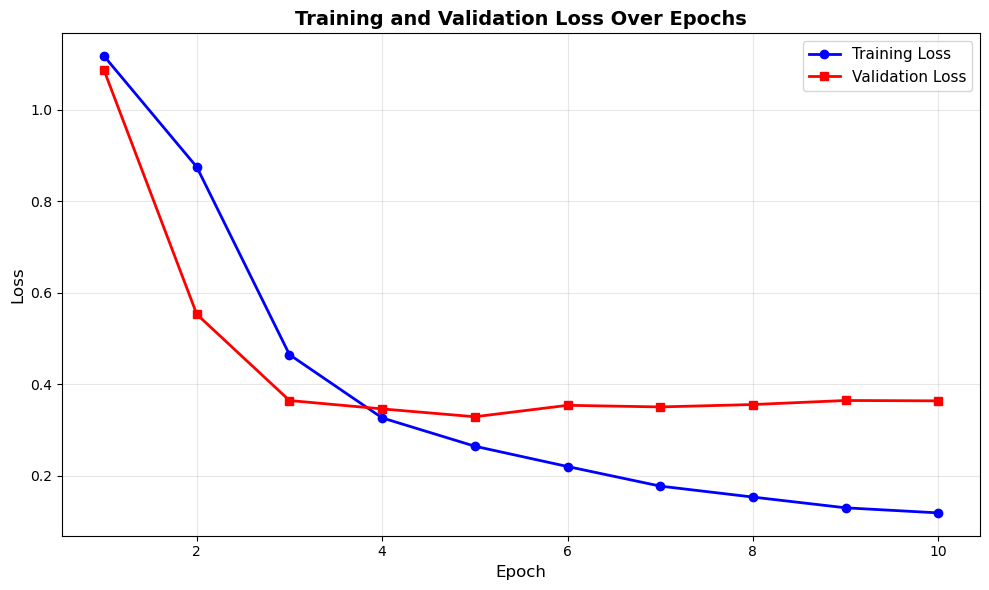

Training losses: [1.1172127997288939, 0.874760875692133, 0.4644453943264289, 0.3261658780154635, 0.2642110148902799, 0.21983344010153755, 0.17700323480807367, 0.15301921980486052, 0.12953018983368014, 0.11844128933658854]
Validation losses: [1.0861921235918999, 0.5527442414313555, 0.36417553201317787, 0.345830918289721, 0.3286827811971307, 0.3536638580262661, 0.3501699222251773, 0.3553966796025634, 0.36424442287534475, 0.3634545346722007]

Best validation loss: 0.3287 at epoch 5


In [12]:
# plot the training loss
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, len(finbert.training_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, finbert.training_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(epochs, finbert.validation_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training losses: {finbert.training_losses}")
print(f"Validation losses: {finbert.validation_losses}")
print(f"\nBest validation loss: {min(finbert.validation_losses):.4f} at epoch {np.argmin(finbert.validation_losses) + 1}")

## Test the model

`bert.evaluate` outputs the DataFrame, where true labels and logit values for each example is given

In [29]:
test_data = finbert.get_data('test')

In [30]:
results = finbert.evaluate(examples=test_data, model=trained_model)

12/08/2025 02:38:18 - INFO - finbert.utils -   *** Example ***
12/08/2025 02:38:18 - INFO - finbert.utils -   guid: test-1
12/08/2025 02:38:18 - INFO - finbert.utils -   tokens: [CLS] finnish scan ##fi ##l , a systems supplier and contract manufacturer electronics industry , reports net sales of eu ##r 49 . 6 mn in the first quarter of 2009 , which are only a per cent smaller than in the corresponding period in 2008 . [SEP]
12/08/2025 02:38:18 - INFO - finbert.utils -   input_ids: 101 6983 13594 8873 2140 1010 1037 3001 17024 1998 3206 7751 8139 3068 1010 4311 5658 4341 1997 7327 2099 4749 1012 1020 24098 1999 1996 2034 4284 1997 2268 1010 2029 2024 2069 1037 2566 9358 3760 2084 1999 1996 7978 2558 1999 2263 1012 102
12/08/2025 02:38:18 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
12/08/2025 02:38:18 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

Testing:   0%|          | 0/16 [00:00<?, ?it/s]

### Prepare the classification report

In [31]:
def report(df, cols=['label','prediction','logits']):
    df_valid = df[df[cols[0]] != 9090].copy()
    
    if len(df_valid) > 0:
        loss = CrossEntropyLoss(weight=finbert.class_weights)(
            torch.tensor(list(df_valid[cols[2]])),
            torch.tensor(list(df_valid[cols[0]]))
        )
        accuracy = (df_valid[cols[0]] == df_valid[cols[1]]).mean()
        balanced_acc = balanced_accuracy_score(df_valid[cols[0]], df_valid[cols[1]])
        print(f"Loss: {loss:.2f}")
        print(f"Accuracy: {accuracy:.2f}")
        print(f"Balanced Accuracy: {balanced_acc:.2f}")
        print("\nClassification Report (with labels):")
        print(classification_report(df_valid[cols[0]], df_valid[cols[1]]))
    else:
        print("No ground truth labels available. Showing predictions only.")
    
    label_names = ['positive', 'negative', 'neutral']
    print("\nPrediction Distribution:")
    for idx, count in df[cols[1]].value_counts().sort_index().items():
        name = label_names[int(idx)] if int(idx) < len(label_names) else f'class_{idx}'
        print(f'  {name}: {count} ({count/len(df)*100:.1f}%)')


In [32]:
results['prediction'] = results.predictions.apply(lambda x: np.argmax(x,axis=0))

In [33]:
report(results,cols=['labels','prediction','predictions'])

Loss: 0.41
Accuracy: 0.83
Balanced Accuracy: 0.86

Classification Report (with labels):
              precision    recall  f1-score   support

           0       0.71      0.86      0.78       146
           1       0.72      0.91      0.81        46
           2       0.93      0.80      0.86       293

    accuracy                           0.83       485
   macro avg       0.79      0.86      0.82       485
weighted avg       0.85      0.83      0.83       485


Prediction Distribution:
  positive: 175 (36.1%)
  negative: 58 (12.0%)
  neutral: 252 (52.0%)


### Evaluate on Validation Set (with labels)

Evaluate the model on validation data which has ground truth labels to get metrics.

In [34]:
# Get validation data (which has labels)
validation_data = finbert.get_data("validation")

# Evaluate on validation set
val_results = finbert.evaluate(examples=validation_data, model=trained_model)
val_results["prediction"] = val_results.predictions.apply(lambda x: np.argmax(x,axis=0))

# Generate full report with metrics
report(val_results, cols=["labels","prediction","predictions"])

12/08/2025 02:38:24 - INFO - finbert.utils -   *** Example ***
12/08/2025 02:38:24 - INFO - finbert.utils -   guid: validation-1
12/08/2025 02:38:24 - INFO - finbert.utils -   tokens: [CLS] ` ` my wife is looking forward to getting a pay ##che ##ck again , ' ' he qui ##pped recently as a six - knot current swirled around his anchored and heavily sponsored jet sl ##ed . [SEP]
12/08/2025 02:38:24 - INFO - finbert.utils -   input_ids: 101 1036 1036 2026 2564 2003 2559 2830 2000 2893 1037 3477 5403 3600 2153 1010 1005 1005 2002 21864 11469 3728 2004 1037 2416 1011 12226 2783 19171 2105 2010 14453 1998 4600 6485 6892 22889 2098 1012 102 0 0 0 0 0 0 0 0
12/08/2025 02:38:24 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
12/08/2025 02:38:24 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:38:24 - INFO

Testing:   0%|          | 0/16 [00:00<?, ?it/s]

Loss: 0.34
Accuracy: 0.84
Balanced Accuracy: 0.87

Classification Report (with labels):
              precision    recall  f1-score   support

           0       0.76      0.86      0.81       136
           1       0.72      0.93      0.81        61
           2       0.93      0.81      0.87       288

    accuracy                           0.84       485
   macro avg       0.80      0.87      0.83       485
weighted avg       0.86      0.84      0.84       485


Prediction Distribution:
  positive: 154 (31.8%)
  negative: 79 (16.3%)
  neutral: 252 (52.0%)


### Get predictions

With the `predict` function, given a piece of text, we split it into a list of sentences and then predict sentiment for each sentence. The output is written into a dataframe. Predictions are represented in three different columns: 

1) `logit`: probabilities for each class

2) `prediction`: predicted label

3) `sentiment_score`: sentiment score calculated as: probability of positive - probability of negative

Below we analyze a paragraph taken out of [this](https://www.economist.com/finance-and-economics/2019/01/03/a-profit-warning-from-apple-jolts-markets) article from The Economist. For comparison purposes, we also put the sentiments predicted with TextBlob.
> Later that day Apple said it was revising down its earnings expectations in the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China. The news rapidly infected financial markets. Apple’s share price fell by around 7% in after-hours trading and the decline was extended to more than 10% when the market opened. The dollar fell by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering some ground. Asian stockmarkets closed down on January 3rd and European ones opened lower. Yields on government bonds fell as investors fled to the traditional haven in a market storm.

In [35]:
text = "Later that day Apple said it was revising down its earnings expectations in \
the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China. \
The news rapidly infected financial markets. Apple’s share price fell by around 7% in after-hours \
trading and the decline was extended to more than 10% when the market opened. The dollar fell \
by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering \
some ground. Asian stockmarkets closed down on January 3rd and European ones opened lower. \
Yields on government bonds fell as investors fled to the traditional haven in a market storm."

In [36]:
cl_path = project_dir/'models'/'classifier_model'/'finbert-sentiment'
cl_path_str = os.path.abspath(str(cl_path))

# Check if the model path exists
if not os.path.exists(cl_path_str):
    raise FileNotFoundError(f"Classifier model path does not exist: {cl_path_str}. Please train the model first or ensure the path is correct.")
else:
    model = AutoModelForSequenceClassification.from_pretrained(cl_path_str, cache_dir=None, num_labels=3, local_files_only=True)

In [37]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/bruno/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [38]:
result = predict(text,model)

12/08/2025 02:38:25 - INFO - root -   Using device: cpu 
12/08/2025 02:38:25 - INFO - finbert.utils -   *** Example ***
12/08/2025 02:38:25 - INFO - finbert.utils -   guid: 0
12/08/2025 02:38:25 - INFO - finbert.utils -   tokens: [CLS] later that day apple said it was rev ##ising down its earnings expectations in the fourth quarter of 2018 , largely because of lower sales and signs of economic weakness in china . [SEP]
12/08/2025 02:38:25 - INFO - finbert.utils -   input_ids: 101 2101 2008 2154 6207 2056 2009 2001 7065 9355 2091 2049 16565 10908 1999 1996 2959 4284 1997 2760 1010 4321 2138 1997 2896 4341 1998 5751 1997 3171 11251 1999 2859 1012 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:38:25 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:38:25 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [39]:
blob = TextBlob(text)
result['textblob_prediction'] = [sentence.sentiment.polarity for sentence in blob.sentences]
result

,sentence,logit,prediction,sentiment_score,textblob_prediction
0,"Later that day Apple said it was revising down its earnings expectations in the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China.","[0.008282585, 0.97492945, 0.016788]",negative,-0.966647,0.051746
1,The news rapidly infected financial markets.,"[0.013534967, 0.9235835, 0.06288152]",negative,-0.910049,0.000000
2,Apple’s share price fell by around 7% in after-hours trading and the decline was extended to more than 10% when the market opened.,"[0.0072200038, 0.97602934, 0.016750686]",negative,-0.968809,0.500000
3,"The dollar fell by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering some ground.","[0.08435716, 0.8955893, 0.020053485]",negative,-0.811232,0.000000
4,Asian stockmarkets closed down on January 3rd and European ones opened lower.,"[0.007388696, 0.9673439, 0.02526743]",negative,-0.959955,-0.051111
5,Yields on government bonds fell as investors fled to the traditional haven in a market storm.,"[0.011691115, 0.95593435, 0.03237449]",negative,-0.944243,0.000000


In [40]:
print(f'Average sentiment is %.2f.' % (result.sentiment_score.mean()))

Average sentiment is -0.93.


Here is another example

In [41]:
text2 = "Shares in the spin-off of South African e-commerce group Naspers surged more than 25% \
in the first minutes of their market debut in Amsterdam on Wednesday. Bob van Dijk, CEO of \
Naspers and Prosus Group poses at Amsterdam's stock exchange, as Prosus begins trading on the \
Euronext stock exchange in Amsterdam, Netherlands, September 11, 2019. REUTERS/Piroschka van de Wouw \
Prosus comprises Naspers’ global empire of consumer internet assets, with the jewel in the crown a \
31% stake in Chinese tech titan Tencent. There is 'way more demand than is even available, so that’s \
good,' said the CEO of Euronext Amsterdam, Maurice van Tilburg. 'It’s going to be an interesting \
hour of trade after opening this morning.' Euronext had given an indicative price of 58.70 euros \
per share for Prosus, implying a market value of 95.3 billion euros ($105 billion). The shares \
jumped to 76 euros on opening and were trading at 75 euros at 0719 GMT."

In [42]:
result2 = predict(text2,model)
blob = TextBlob(text2)
result2['textblob_prediction'] = [sentence.sentiment.polarity for sentence in blob.sentences]

12/08/2025 02:38:25 - INFO - root -   Using device: cpu 
12/08/2025 02:38:25 - INFO - finbert.utils -   *** Example ***
12/08/2025 02:38:25 - INFO - finbert.utils -   guid: 0
12/08/2025 02:38:25 - INFO - finbert.utils -   tokens: [CLS] shares in the spin - off of south african e - commerce group nas ##pers surged more than 25 % in the first minutes of their market debut in amsterdam on wednesday . [SEP]
12/08/2025 02:38:25 - INFO - finbert.utils -   input_ids: 101 6661 1999 1996 6714 1011 2125 1997 2148 3060 1041 1011 6236 2177 17235 7347 18852 2062 2084 2423 1003 1999 1996 2034 2781 1997 2037 3006 2834 1999 7598 2006 9317 1012 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:38:25 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/08/2025 02:38:25 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [43]:
result2

,sentence,logit,prediction,sentiment_score,textblob_prediction
0,Shares in the spin-off of South African e-commerce group Naspers surged more than 25% in the first minutes of their market debut in Amsterdam on Wednesday.,"[0.96129936, 0.009772667, 0.028927952]",positive,0.951527,0.250000
1,"Bob van Dijk, CEO of Naspers and Prosus Group poses at Amsterdam's stock exchange, as Prosus begins trading on the Euronext stock exchange in Amsterdam, Netherlands, September 11, 2019.","[0.019626703, 0.019898407, 0.9604749]",neutral,-0.000272,0.000000
2,"REUTERS/Piroschka van de Wouw Prosus comprises Naspers’ global empire of consumer internet assets, with the jewel in the crown a 31% stake in Chinese tech titan Tencent.","[0.09361966, 0.009757064, 0.89662325]",neutral,0.083863,0.000000
3,"There is 'way more demand than is even available, so that’s good,' said the CEO of Euronext Amsterdam, Maurice van Tilburg.","[0.8715582, 0.009779959, 0.11866176]",positive,0.861778,0.533333
4,'It’s going to be an interesting hour of trade after opening this morning.',"[0.68494415, 0.022057042, 0.29299882]",positive,0.662887,0.500000
5,"Euronext had given an indicative price of 58.70 euros per share for Prosus, implying a market value of 95.3 billion euros ($105 billion).","[0.04985163, 0.013299594, 0.9368488]",neutral,0.036552,0.000000
6,The shares jumped to 76 euros on opening and were trading at 75 euros at 0719 GMT.,"[0.40378317, 0.014712056, 0.5815048]",neutral,0.389071,0.000000


In [44]:
print(f'Average sentiment is %.2f.' % (result2.sentiment_score.mean()))

Average sentiment is 0.43.
